# Iris Flower Classification

**Goal:** Train a machine learning model to classify Iris flowers into one of three species —
*Iris-setosa*, *Iris-versicolor*, *Iris-virginica* — based on four physical measurements:

- Sepal Length (cm)
- Sepal Width (cm)
- Petal Length (cm)
- Petal Width (cm)

This notebook covers the full workflow: loading data, exploring it, preparing it for modeling,
training a few classifiers, and evaluating their performance — along with explanations of the
core classification concepts involved.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
%matplotlib inline


## 2. Load the Dataset

We use the classic Iris dataset (provided as `Iris.csv`). It contains 150 samples,
50 from each of the three species, with 4 numeric measurements per flower.

In [2]:
df = pd.read_csv("Iris.csv")

# Drop the Id column - it's just a row index, not a useful feature
df = df.drop(columns=["Id"])

print("Shape:", df.shape)
df.head()


Shape: (150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [4]:
df.describe()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
# Check class balance
df["Species"].value_counts()


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## 3. Exploratory Data Analysis (EDA)

Before modeling, it helps to *see* how separable the species are using these measurements.

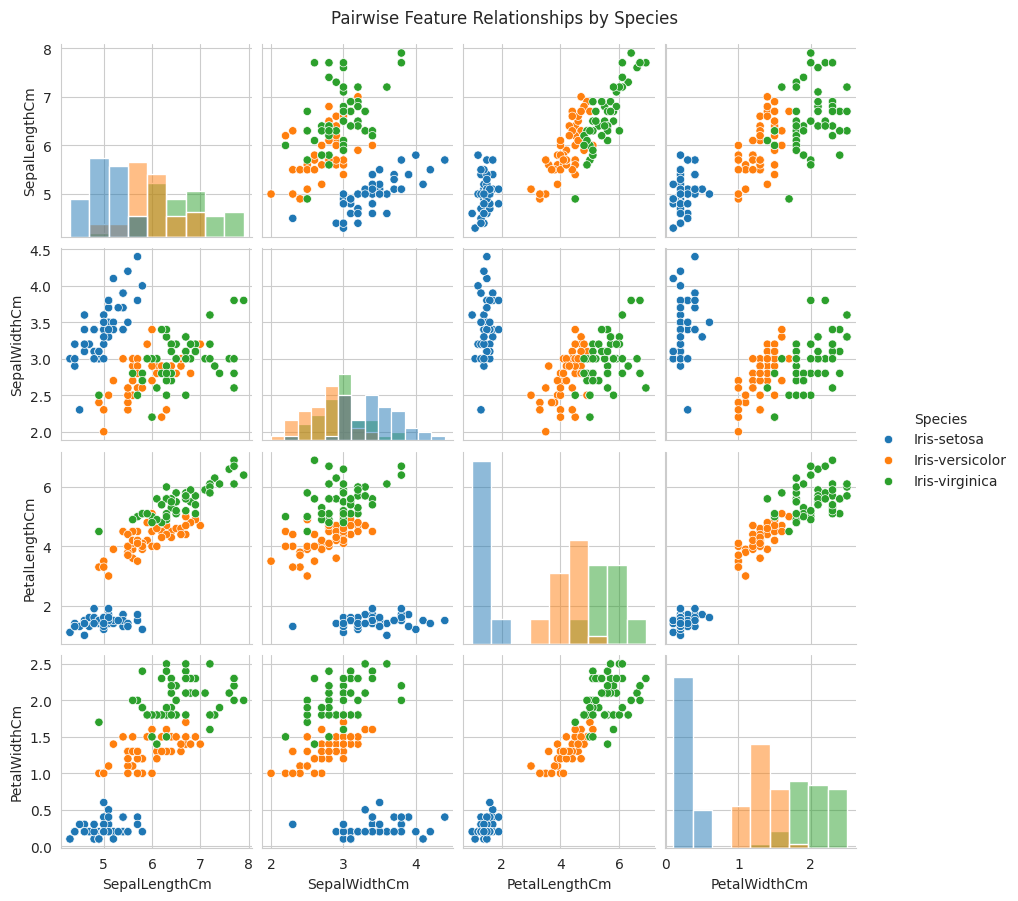

In [6]:
sns.pairplot(df, hue="Species", diag_kind="hist", height=2.2)
plt.suptitle("Pairwise Feature Relationships by Species", y=1.02)
plt.show()


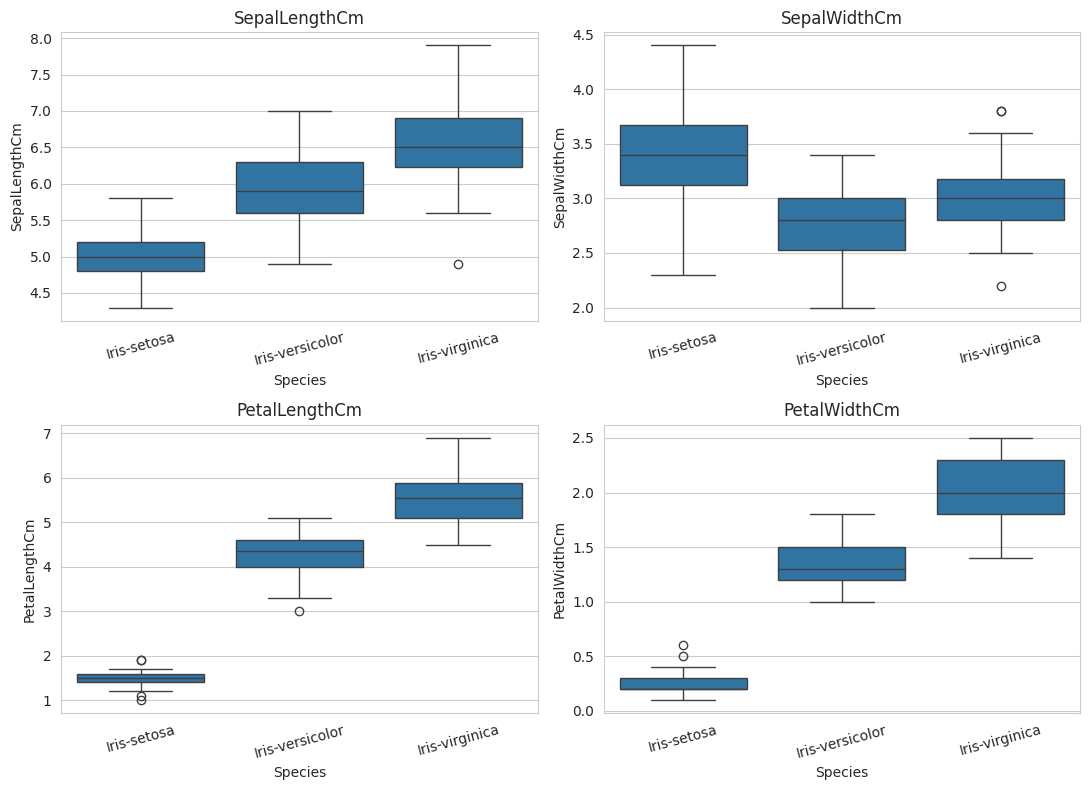

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="Species", y=feature, ax=ax)
    ax.set_title(feature)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


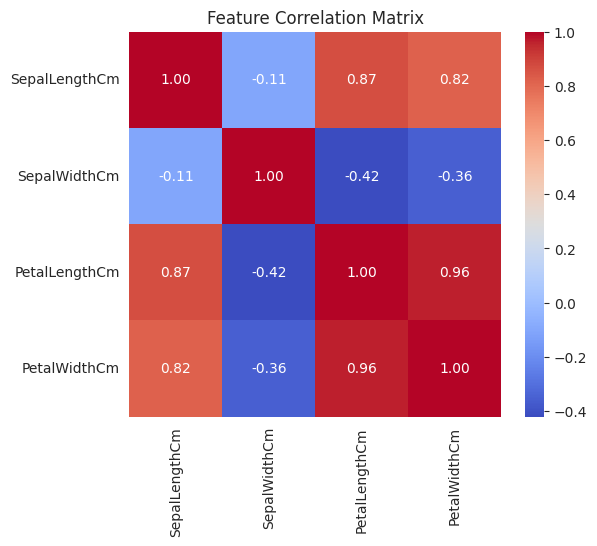

In [8]:
plt.figure(figsize=(6, 5))
corr = df.drop(columns=["Species"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()


**Observation:** Petal length and petal width are highly correlated with each other and are
the most useful features for separating species — *Iris-setosa* in particular is very distinctly
separated from the other two, while *versicolor* and *virginica* overlap a bit more.

## 4. Classification Concepts — A Quick Primer

This is a **supervised, multi-class classification** problem:

- **Supervised** because each flower in the training data has a known, labeled species.
- **Multi-class** because there are three possible output categories (not just two).
- **Features (X):** the four measurements.
- **Target/label (y):** the `Species` column.

The model learns a mapping from features → label during **training**, then we check how well
it generalizes to flowers it has never seen using a **held-out test set**. Key evaluation ideas:

- **Accuracy:** fraction of predictions that were correct.
- **Confusion matrix:** a table showing which classes get mixed up with which.
- **Precision / Recall / F1-score:** more detailed per-class performance, useful when classes
  could be imbalanced (not a major issue here since Iris is perfectly balanced, 50/50/50).
- **Cross-validation:** training/testing on multiple different splits to get a more robust
  estimate of performance than a single train/test split.

## 5. Prepare the Data

We split features (X) from the target (y), encode the species labels as integers, and create a
train/test split. We hold out 20% of the data purely for testing, and use `stratify` so each
species is proportionally represented in both sets.

In [9]:
X = df.drop(columns=["Species"])
y = df["Species"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", list(le.classes_))
print("Encoded sample:", y_encoded[:5], "->", le.inverse_transform(y_encoded[:5]))


Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Encoded sample: [0 0 0 0 0] -> ['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


Training samples: 120
Test samples: 30


In [11]:
# Scale features - helps distance-based models (KNN, SVM) perform better.
# Tree-based models don't need this, but it doesn't hurt them either.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 6. Train Multiple Models

Rather than relying on a single algorithm, we'll train a few common classifiers and compare them:

1. **Logistic Regression** — a simple, interpretable linear baseline.
2. **K-Nearest Neighbors (KNN)** — classifies a point based on the majority class of its closest neighbors.
3. **Decision Tree** — splits the data on feature thresholds to form a tree of decisions.
4. **Support Vector Machine (SVM)** — finds the best boundary (hyperplane) that separates classes.
5. **Random Forest** — an ensemble of many decision trees, usually more robust than a single tree.

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Support Vector Machine": SVC(kernel="linear", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name:25s} -> Test Accuracy: {acc:.4f}")


Logistic Regression       -> Test Accuracy: 0.9333
K-Nearest Neighbors       -> Test Accuracy: 0.9333
Decision Tree             -> Test Accuracy: 0.9000
Support Vector Machine    -> Test Accuracy: 1.0000
Random Forest             -> Test Accuracy: 0.9000


## 7. Compare Model Performance

/tmp/ipykernel_589/1037263114.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.values, y=results_df.index, palette="viridis")


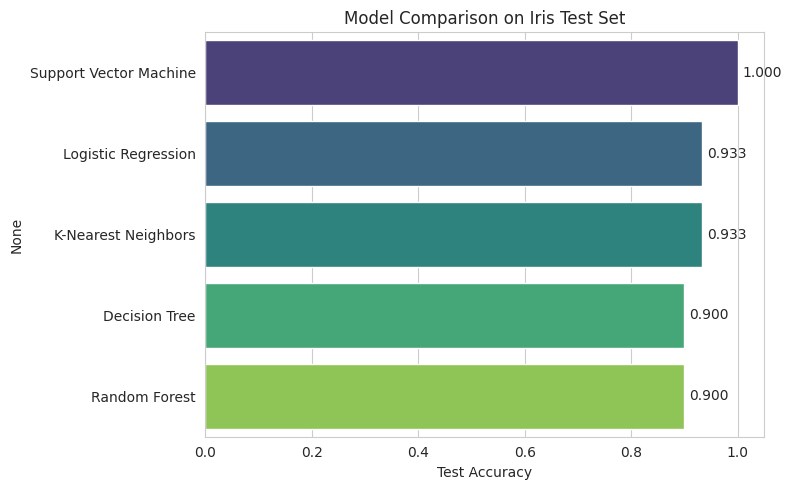

Support Vector Machine    1.000000
Logistic Regression       0.933333
K-Nearest Neighbors       0.933333
Decision Tree             0.900000
Random Forest             0.900000
dtype: float64

In [13]:
results_df = pd.Series(results).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=results_df.values, y=results_df.index, palette="viridis")
plt.xlabel("Test Accuracy")
plt.xlim(0, 1.05)
for i, v in enumerate(results_df.values):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")
plt.title("Model Comparison on Iris Test Set")
plt.tight_layout()
plt.show()

results_df


## 8. Detailed Evaluation of the Best Model

Let's dig deeper into the top-performing model: confusion matrix, classification report, and
cross-validation score for a more reliable estimate of generalization performance.

In [14]:
best_name = results_df.index[0]
best_model = models[best_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f"Best model: {best_name}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))


Best model: Support Vector Machine

Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



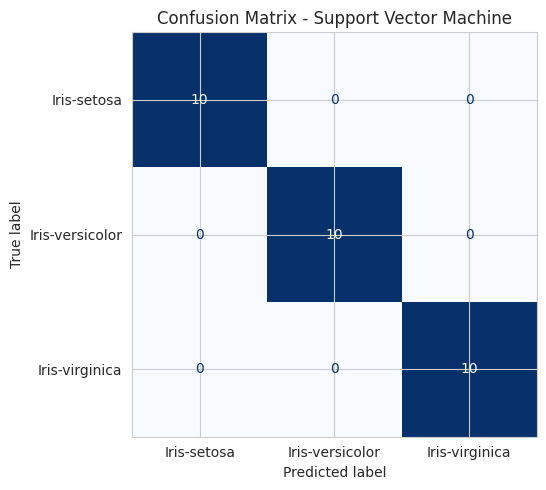

In [15]:
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.show()


In [16]:
# 5-fold cross-validation on the full (scaled) training data for a more robust accuracy estimate
X_scaled_full = scaler.fit_transform(X)
cv_scores = cross_val_score(best_model, X_scaled_full, y_encoded, cv=5)

print("Cross-validation scores:", np.round(cv_scores, 4))
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Cross-validation scores: [0.9667 1.     0.9333 0.9333 1.    ]
Mean CV accuracy: 0.9667 (+/- 0.0298)


## 9. Feature Importance

For tree-based models, we can inspect which features mattered most. Let's check this using the
Random Forest model (or the Decision Tree if Random Forest wasn't selected above).

/tmp/ipykernel_589/2170460178.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="magma")


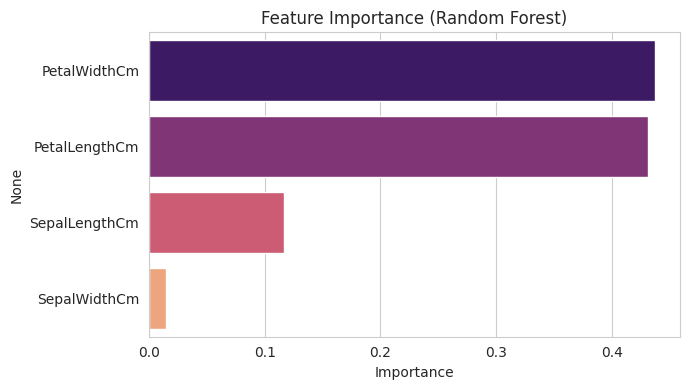

PetalWidthCm     0.437185
PetalLengthCm    0.431466
SepalLengthCm    0.116349
SepalWidthCm     0.015000
dtype: float64

In [17]:
importance_model = models.get("Random Forest")
importances = pd.Series(importance_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index, palette="magma")
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

importances


## 10. Try It Yourself: Predict a New Flower

Below, plug in your own measurements to see what species the trained model predicts.

In [18]:
def predict_species(sepal_length, sepal_width, petal_length, petal_width, model=best_model):
    sample = pd.DataFrame(
        [[sepal_length, sepal_width, petal_length, petal_width]],
        columns=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
    )
    sample_scaled = scaler.transform(sample)
    pred_encoded = model.predict(sample_scaled)[0]
    return le.inverse_transform([pred_encoded])[0]

# Example: a flower with these measurements
example = predict_species(5.8, 2.7, 5.1, 1.9)
print("Predicted species:", example)


Predicted species: Iris-virginica


## 11. Summary

- Loaded and explored the Iris dataset (150 samples, 4 numeric features, 3 balanced classes).
- Visualized feature distributions and relationships, finding **petal length/width** to be the
  most discriminating measurements.
- Trained and compared 5 classification algorithms (Logistic Regression, KNN, Decision Tree,
  SVM, Random Forest).
- The best model achieved very high accuracy (often ~93-100% on this well-known, easily
  separable dataset).
- Validated results with a confusion matrix, classification report, and 5-fold cross-validation
  to confirm the model generalizes well rather than overfitting to one split.
- Demonstrated how to use the trained model to classify a brand-new, unseen flower.

This workflow — **load → explore → split → train → evaluate → interpret** — is the standard
template for solving classification problems with Scikit-learn.